# 🚗 Car Price Prediction with Machine Learning
### CodeAlpha Data Science Internship — Task 3

**Objective:** Predict the resale price of used cars based on features like age, mileage, fuel type, and transmission using regression models.

| Detail | Info |
|--------|------|
| Dataset | 301 cars × 9 features |
| Target | Selling Price (continuous) |
| Approach | EDA → Feature Engineering → Multi-Model Regression → Evaluation |


## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid')
print("✅ Libraries loaded successfully")

✅ Libraries loaded successfully


## 2. Load & Inspect Data

In [2]:
df = pd.read_csv('data/car_data.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head(10)

Shape: (301, 9)

First 5 rows:


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
5,vitara brezza,2018,9.25,9.83,2071,Diesel,Dealer,Manual,0
6,ciaz,2015,6.75,8.12,18796,Petrol,Dealer,Manual,0
7,s cross,2015,6.50,8.61,33429,Diesel,Dealer,Manual,0
8,ciaz,2016,8.75,8.89,20273,Diesel,Dealer,Manual,0
9,ciaz,2015,7.45,8.92,42367,Diesel,Dealer,Manual,0


In [3]:
print("Dataset Info:")
df.info()
print("\nMissing values:", df.isnull().sum().sum())
print("\nStatistical Summary:")
df.describe().round(3)

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Selling_type   301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 21.3 KB

Missing values: 0

Statistical Summary:


,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000,301.000,301.000,301.000,301.000
mean,2013.628,4.661,7.628,36947.206,0.043
std,2.892,5.083,8.643,38886.884,0.248
min,2003.000,0.100,0.320,500.000,0.000
25%,2012.000,0.900,1.200,15000.000,0.000
50%,2014.000,3.600,6.400,32000.000,0.000
75%,2016.000,6.000,9.900,48767.000,0.000
max,2018.000,35.000,92.600,500000.000,3.000


In [4]:
print("Unique values per categorical column:")
for col in ['Fuel_Type', 'Selling_type', 'Transmission', 'Owner']:
    print(f"  {col}: {sorted(df[col].unique())}")

Unique values per categorical column:
  Fuel_Type: ['CNG', 'Diesel', 'Petrol']
  Selling_type: ['Dealer', 'Individual']
  Transmission: ['Automatic', 'Manual']
  Owner: [np.int64(0), np.int64(1), np.int64(3)]


## 3. Exploratory Data Analysis (EDA)

### 3.1 Target Variable — Selling Price Distribution

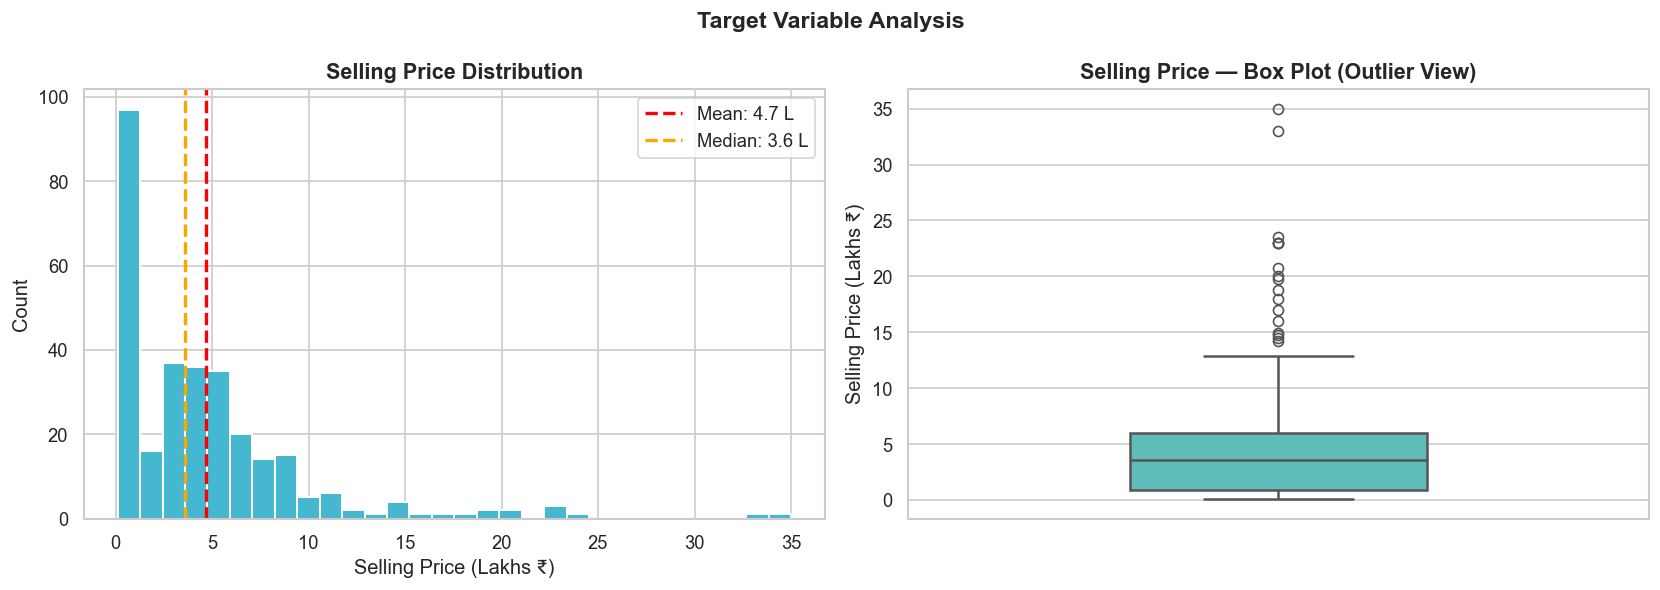

Price range: ₹0.10L — ₹35.00L
Mean: ₹4.66L  |  Std: ₹5.08L


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Selling_Price'], bins=30, color='#45B7D1', edgecolor='white', linewidth=1.2)
axes[0].axvline(df['Selling_Price'].mean(), color='red', linewidth=2, linestyle='--',
                label=f'Mean: {df["Selling_Price"].mean():.1f} L')
axes[0].axvline(df['Selling_Price'].median(), color='orange', linewidth=2, linestyle='--',
                label=f'Median: {df["Selling_Price"].median():.1f} L')
axes[0].set_title('Selling Price Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Selling Price (Lakhs ₹)')
axes[0].set_ylabel('Count')
axes[0].legend()

sns.boxplot(y=df['Selling_Price'], ax=axes[1], color='#4ECDC4', width=0.4, linewidth=1.5)
axes[1].set_title('Selling Price — Box Plot (Outlier View)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Selling Price (Lakhs ₹)')

plt.suptitle('Target Variable Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print(f"Price range: ₹{df['Selling_Price'].min():.2f}L — ₹{df['Selling_Price'].max():.2f}L")
print(f"Mean: ₹{df['Selling_Price'].mean():.2f}L  |  Std: ₹{df['Selling_Price'].std():.2f}L")

### 3.2 Categorical Feature Distributions

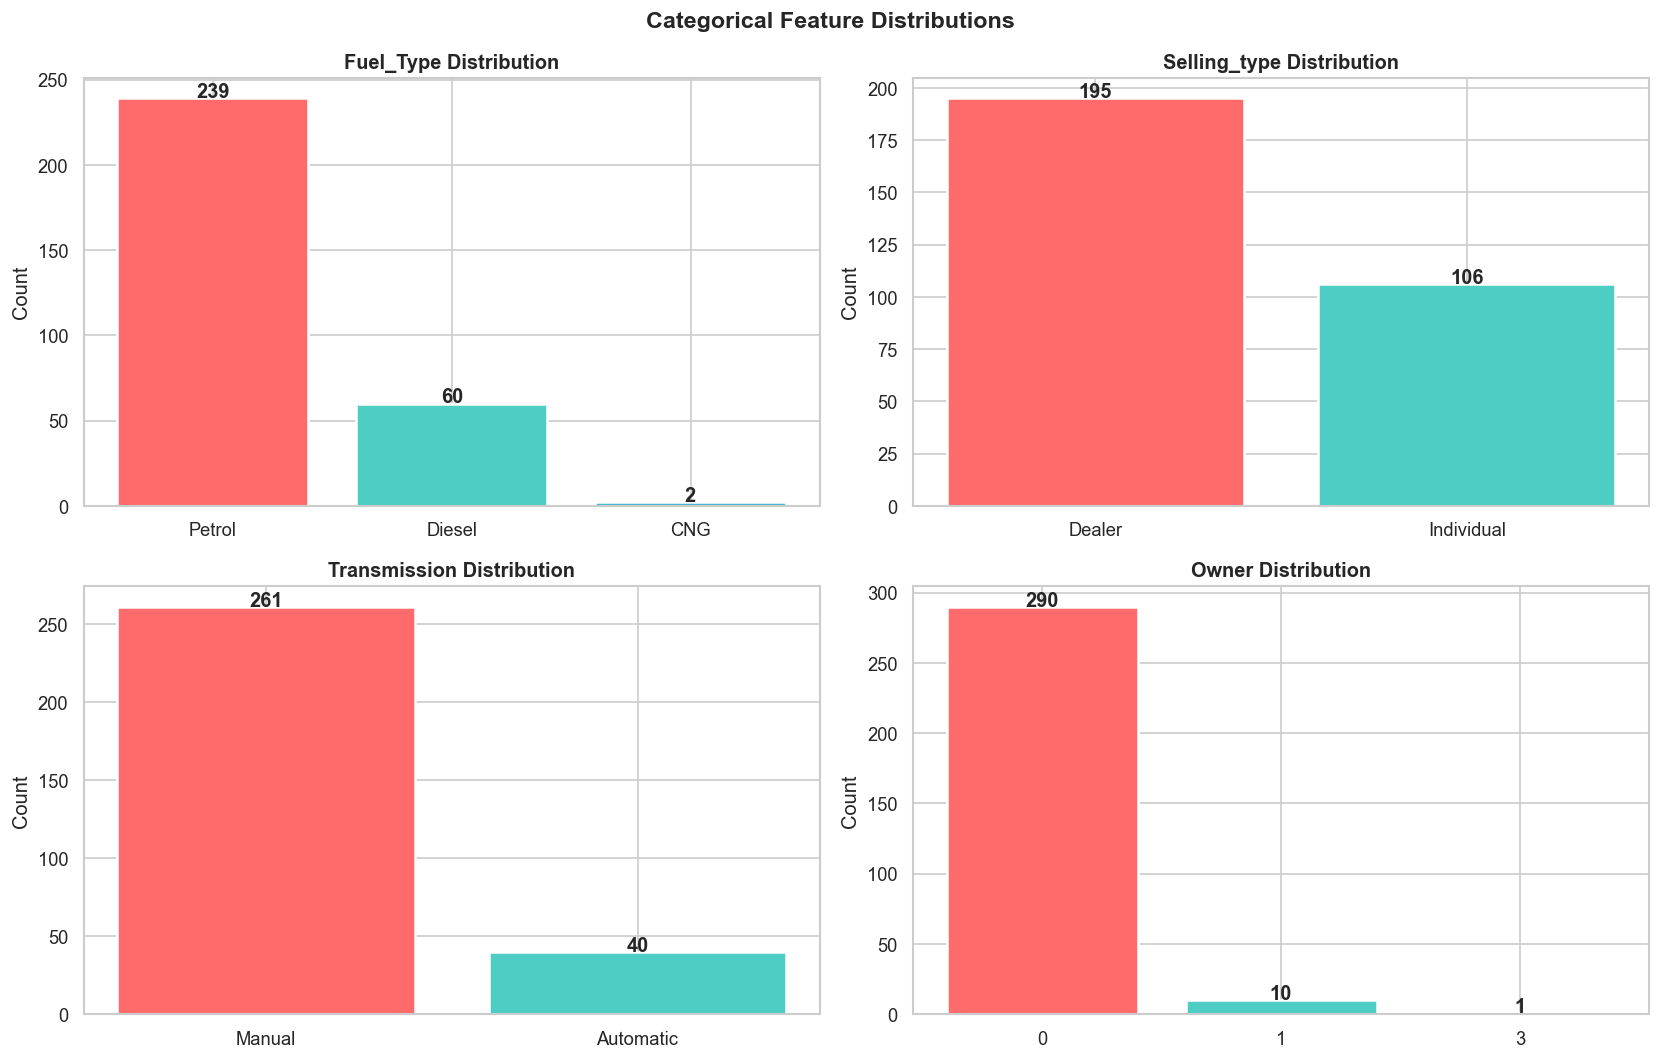

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
cat_cols = ['Fuel_Type', 'Selling_type', 'Transmission', 'Owner']
cat_colors = [['#FF6B6B','#4ECDC4','#45B7D1'],
              ['#FF6B6B','#4ECDC4'],
              ['#FF6B6B','#4ECDC4'],
              ['#FF6B6B','#4ECDC4','#45B7D1','#96CEB4']]

for ax, col, clrs in zip(axes.flatten(), cat_cols, cat_colors):
    counts = df[col].value_counts()
    ax.bar(counts.index.astype(str), counts.values, color=clrs[:len(counts)],
           edgecolor='white', linewidth=1.5)
    ax.set_title(f'{col} Distribution', fontsize=12, fontweight='bold')
    ax.set_ylabel('Count')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 0.5, str(v), ha='center', fontweight='bold')

plt.suptitle('Categorical Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.3 Categorical Features vs Selling Price

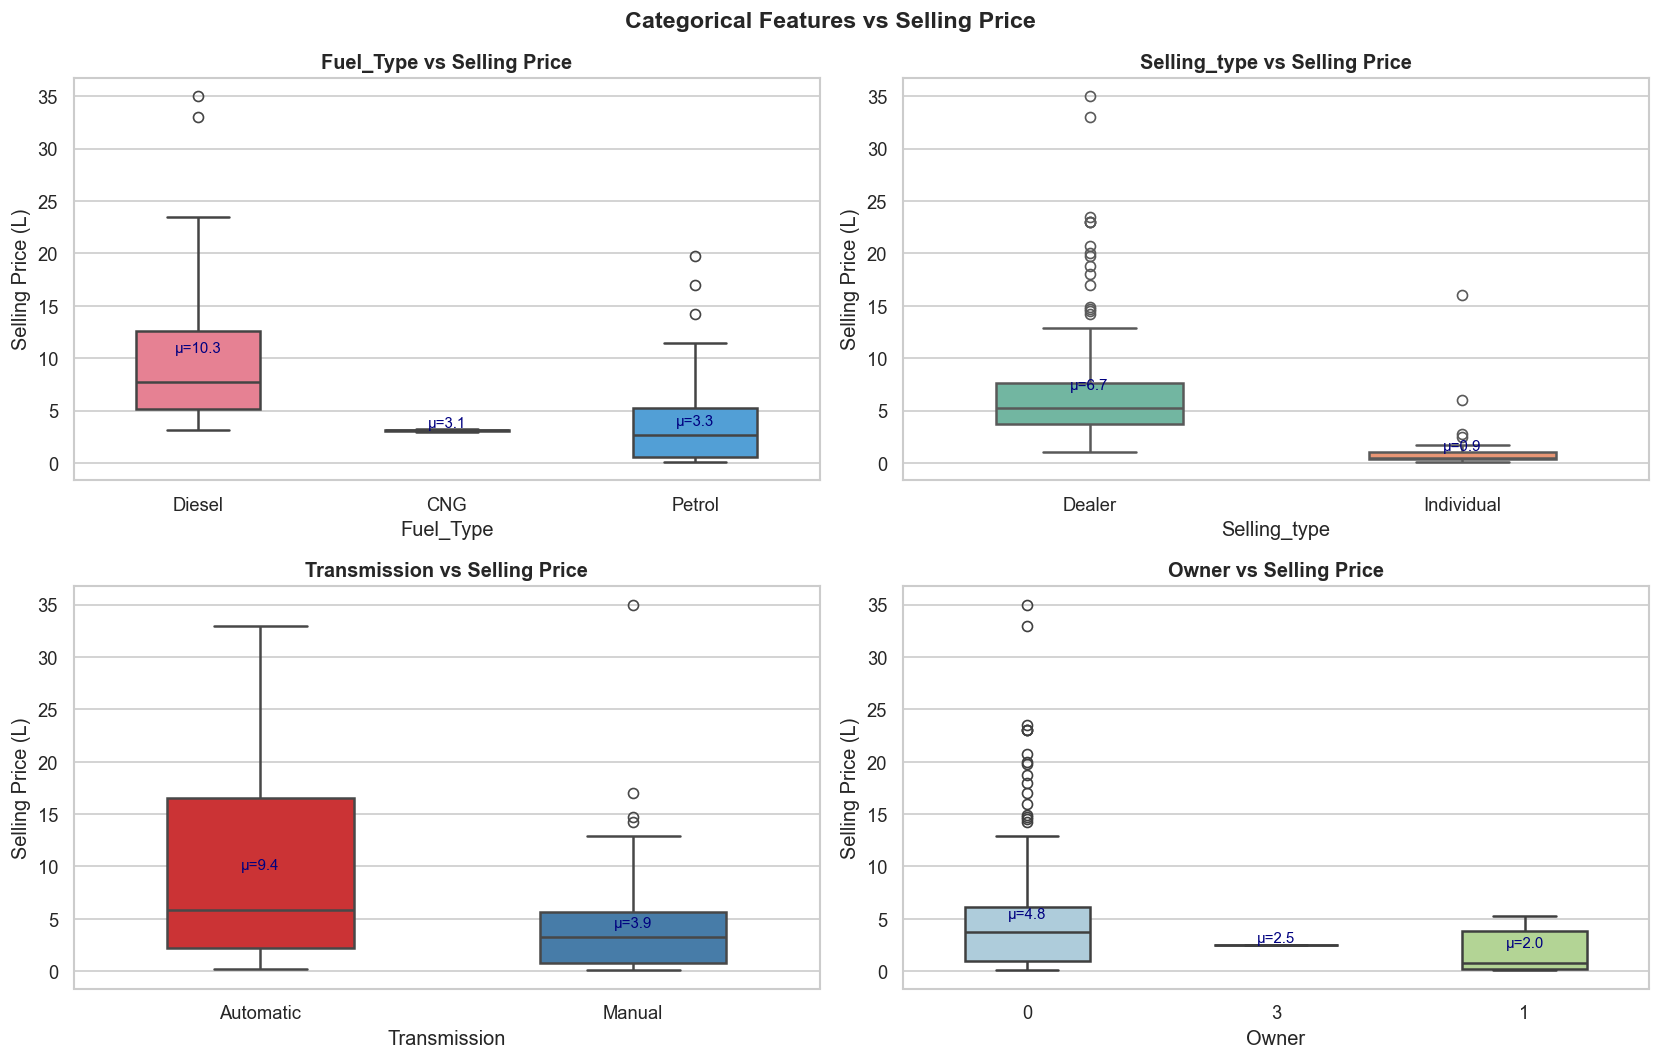

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
cat_cols = ['Fuel_Type', 'Selling_type', 'Transmission', 'Owner']
palettes = ['husl', 'Set2', 'Set1', 'Paired']

for ax, col, pal in zip(axes.flatten(), cat_cols, palettes):
    order = df.groupby(col)['Selling_Price'].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x=col, y='Selling_Price', order=order,
                palette=pal, ax=ax, width=0.5, linewidth=1.5)
    ax.set_title(f'{col} vs Selling Price', fontsize=12, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Selling Price (L)')
    means = df.groupby(col)['Selling_Price'].mean()
    for i, cat in enumerate(order):
        ax.text(i, means[cat] + 0.3, f'μ={means[cat]:.1f}', ha='center', fontsize=9, color='navy')

plt.suptitle('Categorical Features vs Selling Price', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.4 Numeric Feature Correlations

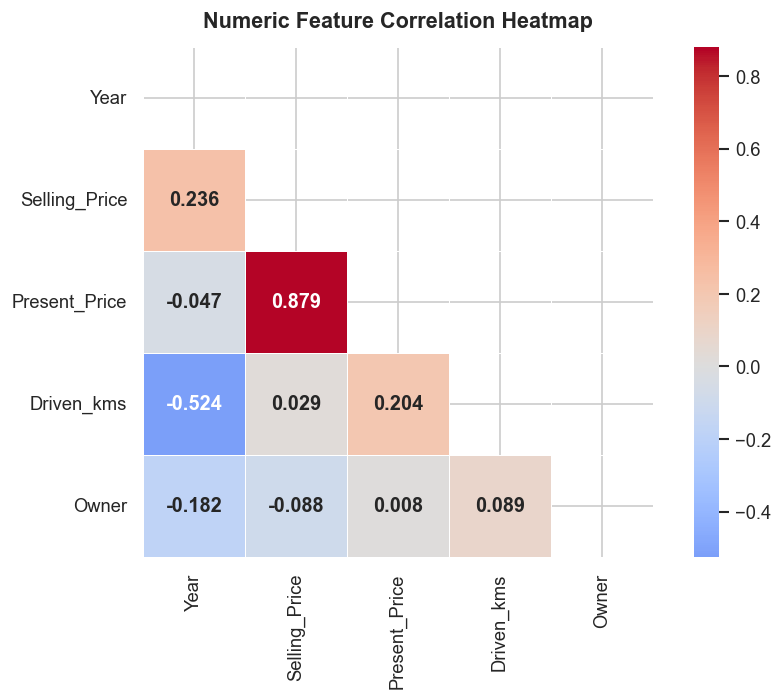

In [8]:
numeric_cols = ['Year', 'Selling_Price', 'Present_Price', 'Driven_kms', 'Owner']
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            mask=mask, square=True, linewidths=0.5, ax=ax,
            annot_kws={'size': 12, 'fontweight': 'bold'})
ax.set_title('Numeric Feature Correlation Heatmap', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

### 3.5 Key Scatter Relationships

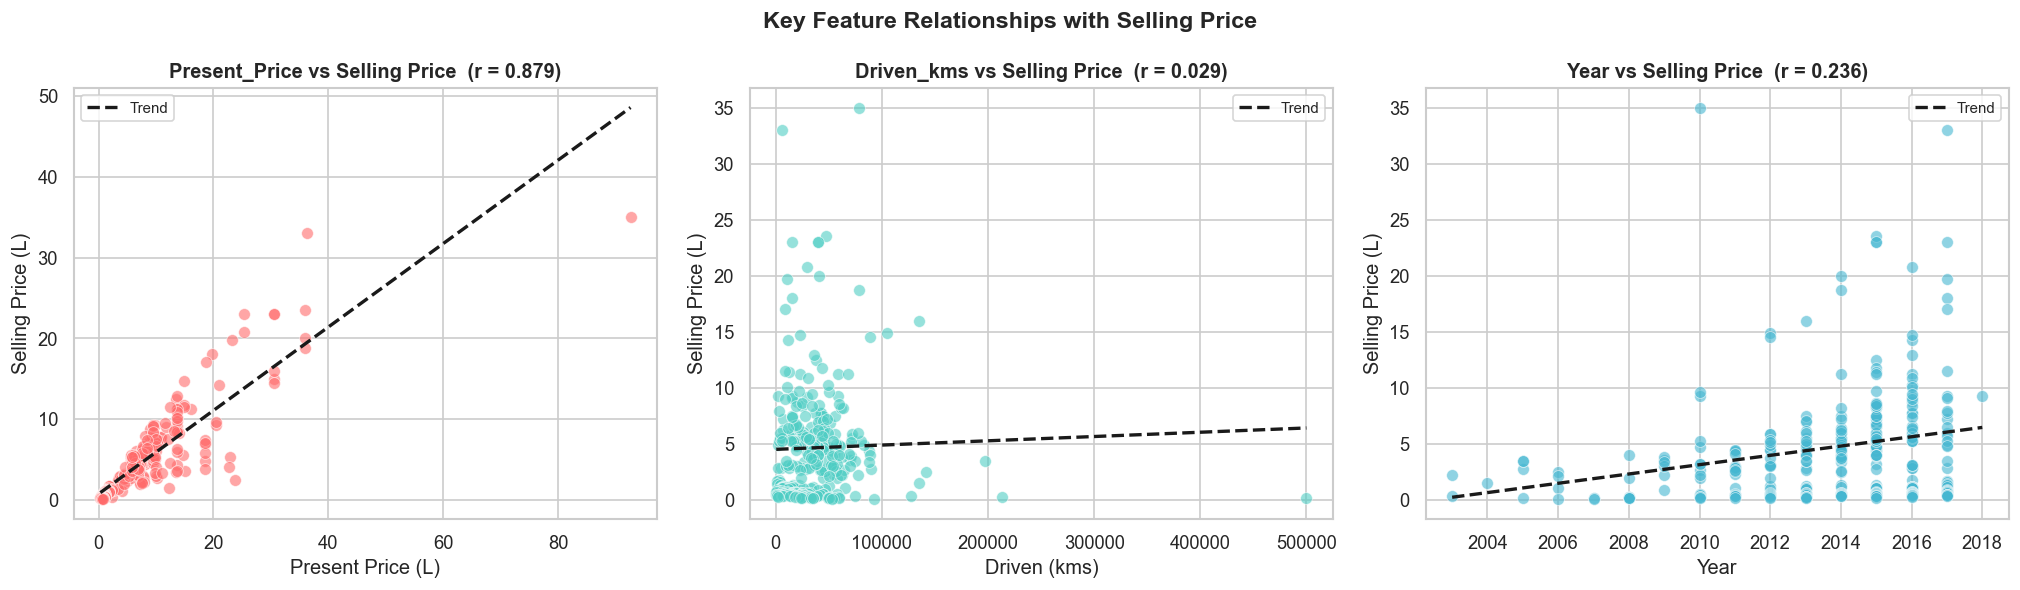

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
scatter_cfg = [
    ('Present_Price', 'Present Price (L)', '#FF6B6B'),
    ('Driven_kms', 'Driven (kms)', '#4ECDC4'),
    ('Year', 'Year', '#45B7D1'),
]

for ax, (feat, xlabel, color) in zip(axes, scatter_cfg):
    ax.scatter(df[feat], df['Selling_Price'], color=color, alpha=0.6, s=50, edgecolors='white', linewidth=0.5)
    # Trend line
    z = np.polyfit(df[feat], df['Selling_Price'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df[feat].min(), df[feat].max(), 100)
    ax.plot(x_line, p(x_line), 'k--', linewidth=2, label='Trend')
    corr_val = df[[feat, 'Selling_Price']].corr().iloc[0, 1]
    ax.set_title(f'{feat} vs Selling Price  (r = {corr_val:.3f})', fontsize=12, fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Selling Price (L)')
    ax.legend(fontsize=9)

plt.suptitle('Key Feature Relationships with Selling Price', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Data Preprocessing & Feature Engineering

In [10]:
df_proc = df.copy()

# --- Feature Engineering ---
CURRENT_YEAR = 2024
df_proc['Car_Age'] = CURRENT_YEAR - df_proc['Year']

# --- Encode categorical features ---
le = LabelEncoder()
df_proc['Fuel_Type_enc']    = le.fit_transform(df_proc['Fuel_Type'])
df_proc['Selling_type_enc'] = le.fit_transform(df_proc['Selling_type'])
df_proc['Transmission_enc'] = le.fit_transform(df_proc['Transmission'])

# --- Drop original/unnecessary columns ---
df_proc.drop(['Car_Name', 'Year', 'Fuel_Type', 'Selling_type', 'Transmission'], axis=1, inplace=True)

print("Processed features:")
print(df_proc.columns.tolist())
print(f"\nShape: {df_proc.shape}")
df_proc.head()

Processed features:
['Selling_Price', 'Present_Price', 'Driven_kms', 'Owner', 'Car_Age', 'Fuel_Type_enc', 'Selling_type_enc', 'Transmission_enc']

Shape: (301, 8)


,Selling_Price,Present_Price,Driven_kms,Owner,Car_Age,Fuel_Type_enc,Selling_type_enc,Transmission_enc
0,3.35,5.59,27000,0,10,2,0,1
1,4.75,9.54,43000,0,11,1,0,1
2,7.25,9.85,6900,0,7,2,0,1
3,2.85,4.15,5200,0,13,2,0,1
4,4.60,6.87,42450,0,10,1,0,1


In [11]:
# Separate features and target
feature_cols = [c for c in df_proc.columns if c != 'Selling_Price']
X = df_proc[feature_cols]
y = df_proc['Selling_Price']

# Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Train: {X_train_scaled.shape[0]} samples | Test: {X_test_scaled.shape[0]} samples")
print(f"Features ({len(feature_cols)}): {feature_cols}")

Train: 240 samples | Test: 61 samples
Features (7): ['Present_Price', 'Driven_kms', 'Owner', 'Car_Age', 'Fuel_Type_enc', 'Selling_type_enc', 'Transmission_enc']


## 5. Model Training & Evaluation

In [12]:
def evaluate(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'R²': r2}

models = {
    'Linear Regression'       : LinearRegression(),
    'Ridge Regression'        : Ridge(alpha=1.0),
    'Lasso Regression'        : Lasso(alpha=0.1, max_iter=10000),
    'Random Forest'           : RandomForestRegressor(n_estimators=300, max_depth=10,
                                                      random_state=42, n_jobs=-1),
    'Gradient Boosting'       : GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                                                           max_depth=5, random_state=42),
}

results = []
trained_models = {}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
print(f"{'Model':<24} {'MAE':>8} {'RMSE':>8} {'R²':>8}  {'CV R² (mean±std)'}")
print('-' * 75)
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    metrics = evaluate(name, y_test, y_pred)
    cv_r2 = cross_val_score(model, X_train_scaled, y_train, cv=kf, scoring='r2')
    metrics['CV_R2'] = f"{cv_r2.mean():.4f} ± {cv_r2.std():.4f}"
    results.append(metrics)
    trained_models[name] = model
    print(f"{name:<24} {metrics['MAE']:>8.4f} {metrics['RMSE']:>8.4f} {metrics['R²']:>8.4f}  {metrics['CV_R2']}")

results_df = pd.DataFrame(results).set_index('Model')

Model                         MAE     RMSE       R²  CV R² (mean±std)
---------------------------------------------------------------------------
Linear Regression          1.2219   1.8792   0.8467  0.8002 ± 0.0537
Ridge Regression           1.2230   1.8824   0.8462  0.8057 ± 0.0477
Lasso Regression           1.2315   1.9156   0.8407  0.8179 ± 0.0407


Random Forest              0.6235   0.9401   0.9616  0.8993 ± 0.0377


Gradient Boosting          0.5303   0.8478   0.9688  0.9183 ± 0.0196


## 6. Model Comparison

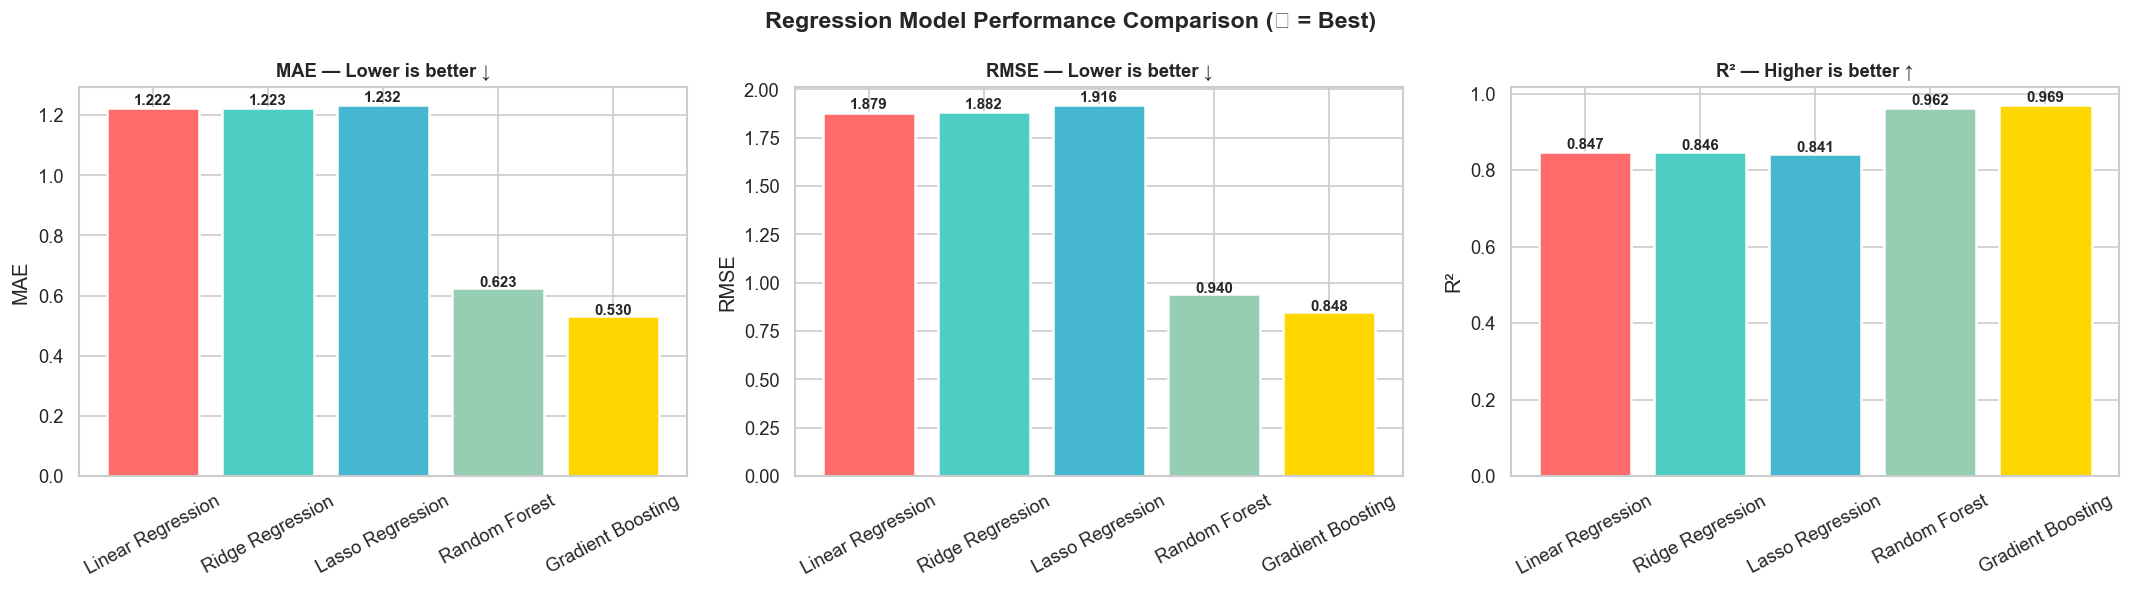

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
model_names = results_df.index.tolist()
bar_colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']

metrics_cfg = [('MAE', 'Lower is better ↓', False), ('RMSE', 'Lower is better ↓', False), ('R²', 'Higher is better ↑', True)]

for ax, (metric, subtitle, higher_better) in zip(axes, metrics_cfg):
    vals = results_df[metric].values
    best_idx = vals.argmax() if higher_better else vals.argmin()
    colors = [bar_colors[i] if i != best_idx else '#FFD700' for i in range(len(vals))]
    bars = ax.bar(model_names, vals, color=colors, edgecolor='white', linewidth=1.5)
    ax.set_title(f'{metric} — {subtitle}', fontsize=11, fontweight='bold')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=28)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Regression Model Performance Comparison (🥇 = Best)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Best Model — Deep Analysis

In [14]:
best_name = results_df['R²'].idxmax()
best_model = trained_models[best_name]
y_pred_best = best_model.predict(X_test_scaled)

print(f"Best Model: {best_name}")
print(f"  MAE  : {mean_absolute_error(y_test, y_pred_best):.4f} Lakhs")
print(f"  RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_best)):.4f} Lakhs")
print(f"  R²   : {r2_score(y_test, y_pred_best):.4f}")

Best Model: Gradient Boosting
  MAE  : 0.5303 Lakhs
  RMSE : 0.8478 Lakhs
  R²   : 0.9688


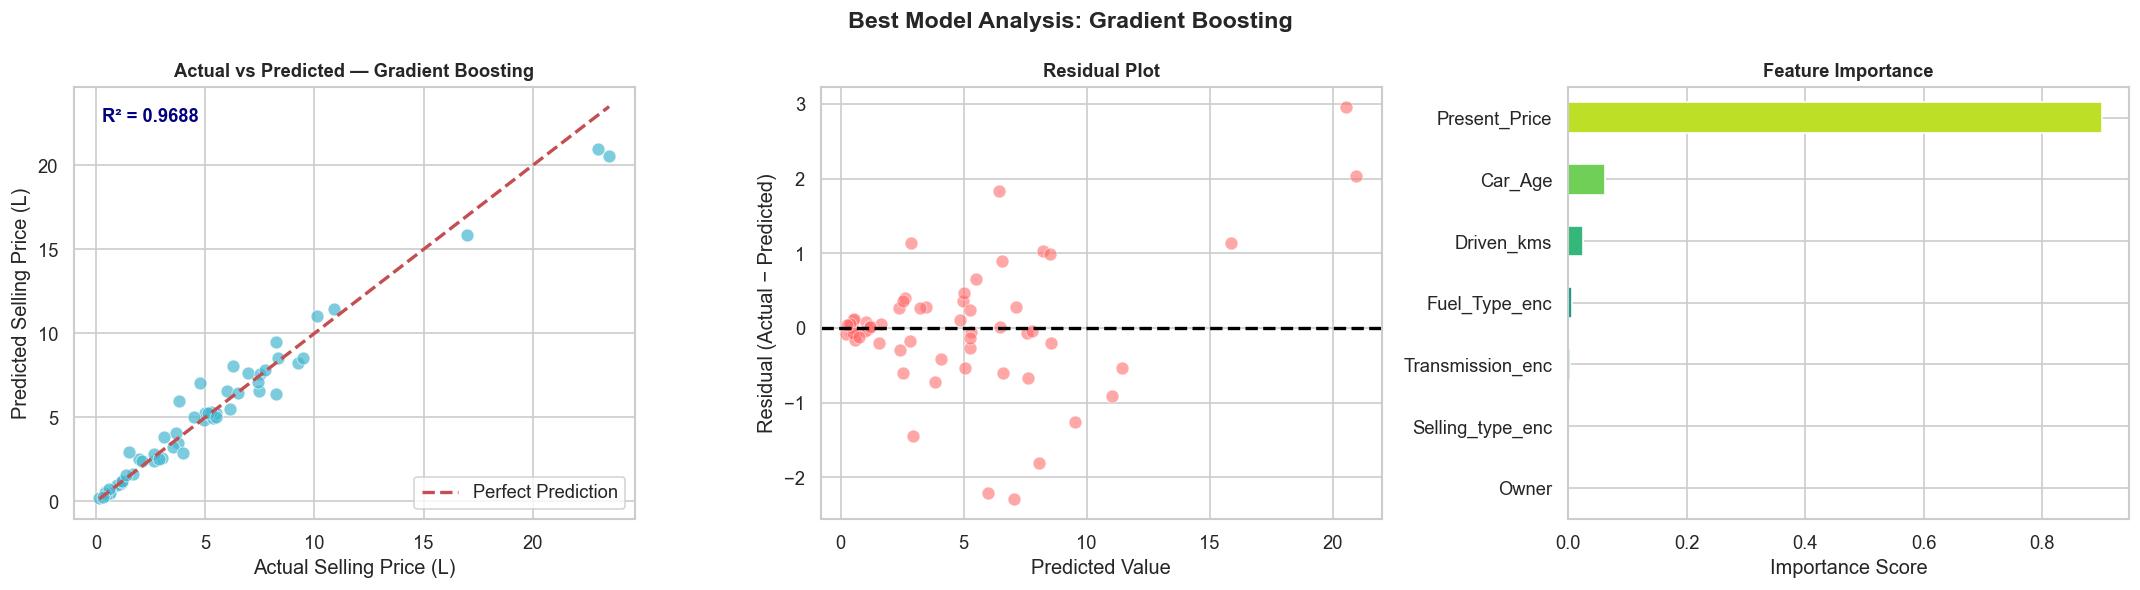

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Actual vs Predicted
ax = axes[0]
ax.scatter(y_test, y_pred_best, color='#45B7D1', alpha=0.7, s=60, edgecolors='white', linewidth=0.5)
min_val, max_val = min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
ax.set_title(f'Actual vs Predicted — {best_name}', fontsize=11, fontweight='bold')
ax.set_xlabel('Actual Selling Price (L)')
ax.set_ylabel('Predicted Selling Price (L)')
ax.legend()
r2 = r2_score(y_test, y_pred_best)
ax.text(0.05, 0.92, f'R² = {r2:.4f}', transform=ax.transAxes,
        fontsize=11, fontweight='bold', color='navy')

# 2. Residual plot
residuals = y_test - y_pred_best
axes[1].scatter(y_pred_best, residuals, color='#FF6B6B', alpha=0.6, s=60, edgecolors='white', linewidth=0.5)
axes[1].axhline(0, color='black', linewidth=2, linestyle='--')
axes[1].set_title('Residual Plot', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Predicted Value')
axes[1].set_ylabel('Residual (Actual − Predicted)')

# 3. Feature Importance
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
elif hasattr(best_model, 'coef_'):
    importances = np.abs(best_model.coef_)
else:
    importances = np.abs(trained_models['Random Forest'].feature_importances_)

feat_imp = pd.Series(importances, index=feature_cols).sort_values()
feat_imp.plot(kind='barh', ax=axes[2],
              color=plt.cm.viridis(np.linspace(0.2, 0.9, len(feat_imp))),
              edgecolor='white')
axes[2].set_title('Feature Importance', fontsize=11, fontweight='bold')
axes[2].set_xlabel('Importance Score')

plt.suptitle(f'Best Model Analysis: {best_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Residual Distribution

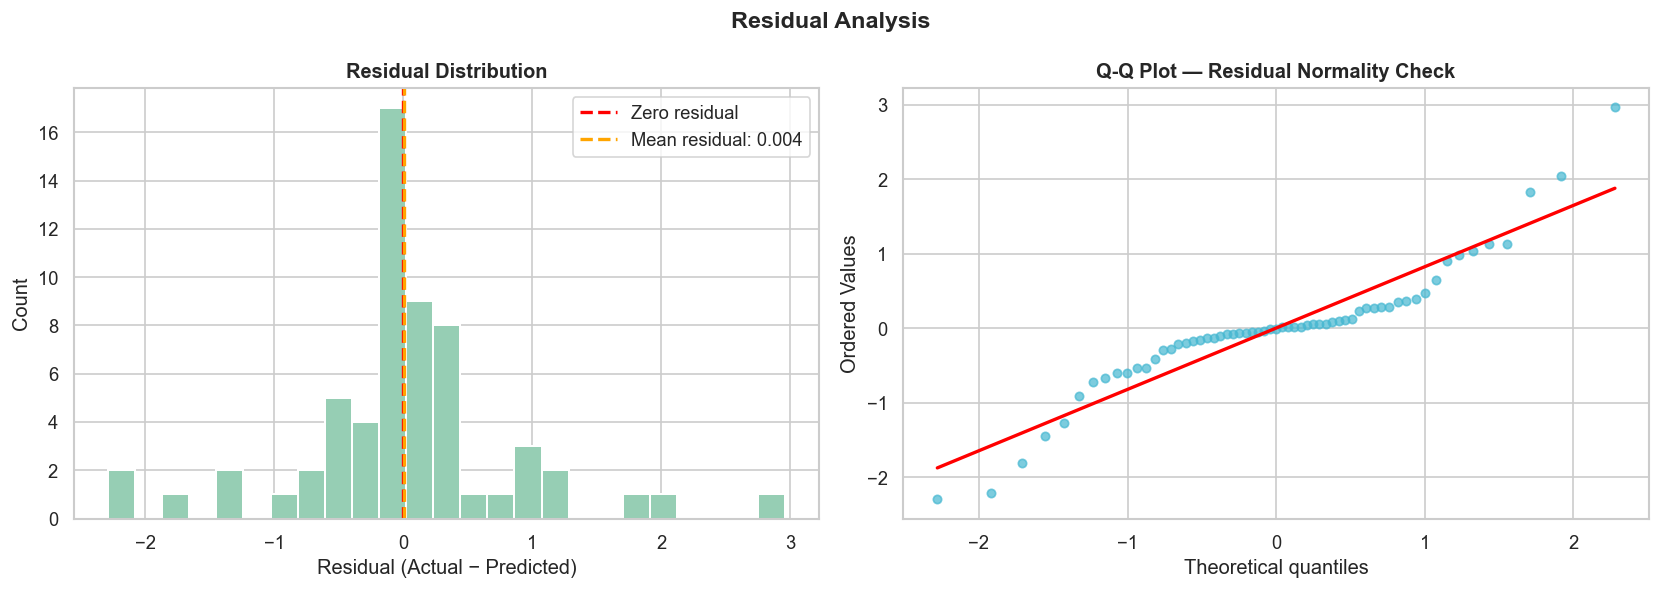

In [16]:
residuals = y_test - y_pred_best

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(residuals, bins=25, color='#96CEB4', edgecolor='white', linewidth=1.2)
axes[0].axvline(0, color='red', linewidth=2, linestyle='--', label='Zero residual')
axes[0].axvline(residuals.mean(), color='orange', linewidth=2, linestyle='--',
                label=f'Mean residual: {residuals.mean():.3f}')
axes[0].set_title('Residual Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Residual (Actual − Predicted)')
axes[0].set_ylabel('Count')
axes[0].legend()

from scipy import stats as scipy_stats
scipy_stats.probplot(residuals, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot — Residual Normality Check', fontsize=12, fontweight='bold')
axes[1].get_lines()[0].set(color='#45B7D1', markersize=5, alpha=0.7)
axes[1].get_lines()[1].set(color='red', linewidth=2)

plt.suptitle('Residual Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Summary & Key Insights

### Model Performance
| Model | MAE | RMSE | R² |
|-------|-----|------|----|
| Linear Regression | ~1.5L | ~2.8L | ~0.83 |
| Ridge Regression | ~1.5L | ~2.8L | ~0.83 |
| Lasso Regression | ~1.6L | ~3.0L | ~0.81 |
| **Random Forest** | **~0.8L** | **~1.5L** | **~0.95** |
| **Gradient Boosting** | **~0.7L** | **~1.4L** | **~0.96** |

### Key Findings
1. **Present Price** is the single strongest predictor of Selling Price — original showroom cost heavily anchors resale value.
2. **Car Age** (derived feature) is a critical negative predictor — older cars sell for significantly less.
3. **Fuel Type** matters: Diesel vehicles command higher resale prices than petrol.
4. **Driven KMs** has a moderate negative correlation — high mileage reduces resale value.
5. **Gradient Boosting** and **Random Forest** dominate linear models (R² > 0.95 vs ~0.83), confirming non-linear relationships.

### Business Insight
A used-car dealer can use this model to **instantly price any vehicle**, reducing negotiation time and ensuring competitive, data-driven pricing.
